**Importing Libraries**

In [1]:
import ROOT
from iminuit import Minuit, cost

# we also need a cost function to fit and import the LeastSquares function
from iminuit.cost import LeastSquares

# display iminuit version
import iminuit

import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from numpy import inf
import pandas as pd
import csv
# from scipy.optimize import curve_fit

Welcome to JupyROOT 6.26/06


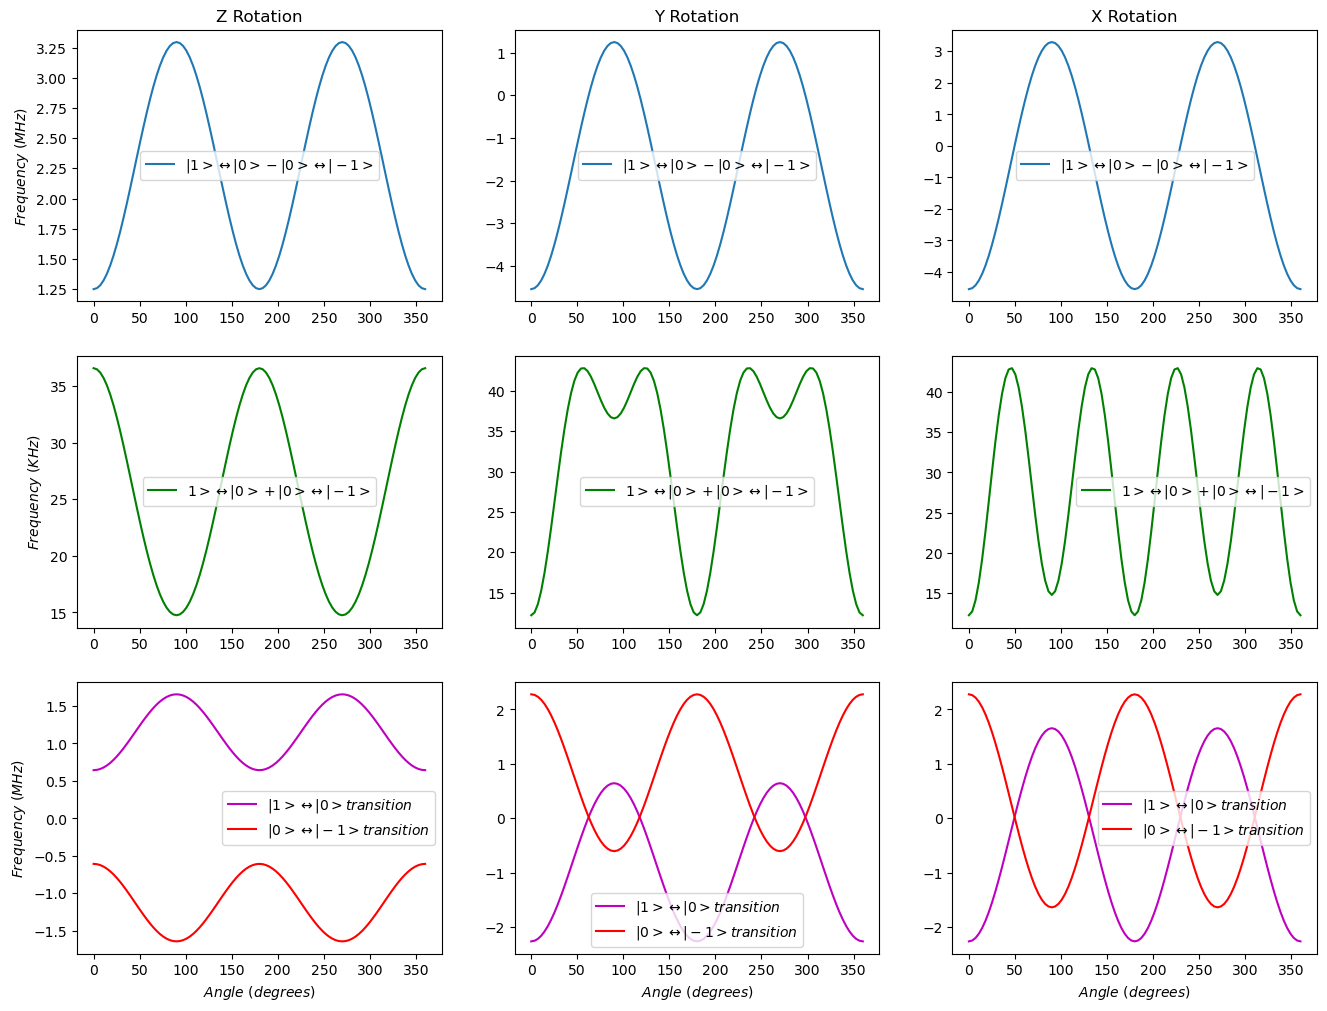

In [2]:
fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(16,12))

# input from z rot file
df1= pd.read_csv('freq_z_rot.csv', header = 0)

x = df1['angle']
y_sz = df1['fre_sum']/1E3
y_dz = df1['freq_diff']/1E6
y_1Dz = df1['freq_1D']/1E6 #freq of |1> -> |0>
y_2Dz = df1['freq_2D']/1E6 #freq of |0> -> |-1>

axes[0,0].plot(x,y_dz, '-', label = r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
axes[0,0].set_title('Z Rotation')
#axes[0,0].set_ylabel(r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$' + '\n' + 'frequency(Hz)')
axes[0,0].set_ylabel(r'$Frequency\ (MHz)$')
axes[0,0].legend()

axes[1,0].plot(x,y_sz, '-g', label = r'$1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
#axes[1,0].set_ylabel(r'$|1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$' + '\n' + 'frequency(KHz)')
axes[1,0].set_ylabel(r'$Frequency\ (KHz)$')
axes[1,0].legend()

axes[2,0].plot(x,y_1Dz, '-m', label = r'$|1>\leftrightarrow|0> transition$')
axes[2,0].plot(x,y_2Dz, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
axes[2,0].set_ylabel(r'$Frequency\ (MHz)$')
axes[2,0].set_xlabel(r'$Angle\ (degrees)$')
axes[2,0].legend()

# input from y rot file
df2= pd.read_csv('freq_y_rot.csv', header = 0)

x = df2['angle']
y_sy = df2['fre_sum']/1E3
y_dy = df2['freq_diff']/1E6
y_1Dy = df2['freq_1D']/1E6 #freq of |1> -> |0>
y_2Dy = df2['freq_2D']/1E6 #freq of |0> -> |-1>
axes[0,1].plot(x,y_dy, '-', label = r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
axes[0,1].set_title('Y Rotation')
axes[0,1].legend()
axes[1,1].plot(x,y_sy, '-g', label = r'$1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
axes[1,1].legend()

axes[2,1].plot(x,y_1Dy, '-m', label = r'$|1>\leftrightarrow|0> transition$')
axes[2,1].plot(x,y_2Dy, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
axes[2,1].set_xlabel(r'$Angle\ (degrees)$')
axes[2,1].legend()

# input from x rot file
df3= pd.read_csv('freq_x_rot.csv', header = 0)

x = df3['angle']
y_sx = df3['fre_sum']/1E3
y_dx = df3['freq_diff']/1E6
y_1Dx = df3['freq_1D']/1E6 #freq of |1> -> |0>
y_2Dx = df3['freq_2D']/1E6 #freq of |0> -> |-1>
axes[0,2].plot(x,y_dx, '-', label = r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
axes[0,2].set_title('X Rotation')
axes[0,2].legend()

axes[1,2].plot(x,y_sx, '-g', label = r'$1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
axes[1,2].legend()

axes[2,2].plot(x,y_1Dx, '-m', label = r'$|1>\leftrightarrow|0> transition$')
axes[2,2].plot(x,y_2Dx, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
axes[2,2].set_xlabel(r'$Angle\ (degrees)$')
axes[2,2].legend()


# plt.xlabel("Angle")
# plt.ylabel("frequency (Hz)")
# for ax in axes.flat:
#     ax.set(xlabel='Angle')

# Hide x labels and tick labels for top plots and y ticks for right plots.
# for ax in axes.flat:
#     ax.label_outer()


In [3]:
df = pd.read_csv("noacsfreq_z_rot.csv")
x= df["angle"]
y_d = df["freq_diff"]
y_s = df["fre_sum"]
y_1D = df["freq_1D"]
y_2D = df["freq_2D"]

Text(0, 0.5, 'frequency (Hz)')

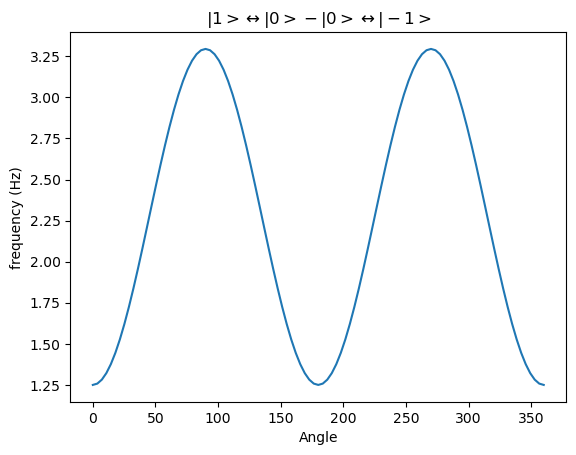

In [4]:
plt.plot(x,y_dz, '-')
plt.title(r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
plt.xlabel("Angle")
plt.ylabel("frequency (Hz)")

Text(0, 0.5, '$Frequency (Hz)$')

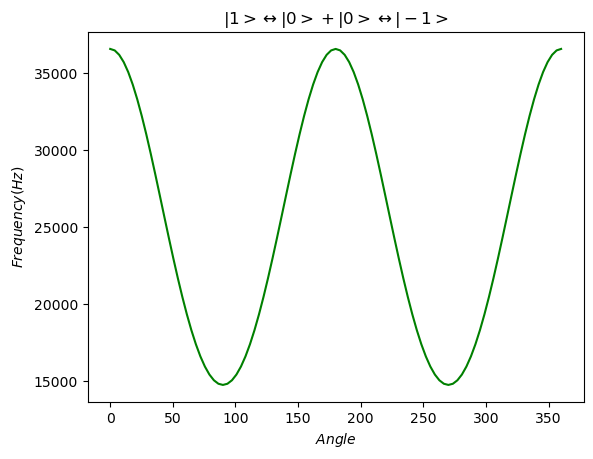

In [5]:
plt.plot(x,y_s, '-g')
plt.title(r'$|1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')

Text(0, 0.5, '$Frequency (Hz)$')

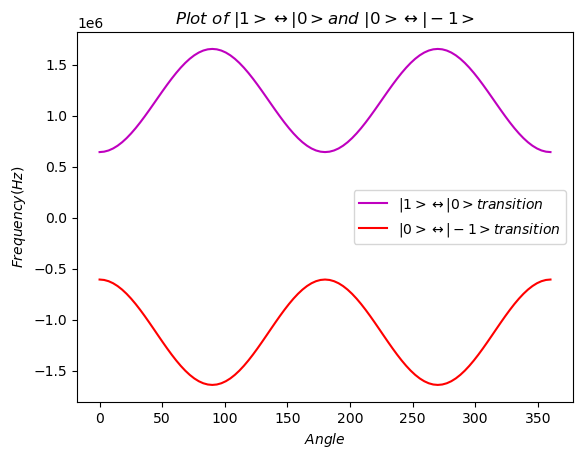

In [6]:
plt.plot(x,y_1D, '-m', label = r'$|1>\leftrightarrow|0> transition$')
plt.plot(x,y_2D, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
plt.title(r'$Plot\ of\ |1>\leftrightarrow|0> and\ |0>\leftrightarrow|-1>$')
plt.legend()

plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')


Checking if |1> -> |0> and |0> -> |-1> transitions are same or not

Text(0, 0.5, '$Frequency (Hz)$')

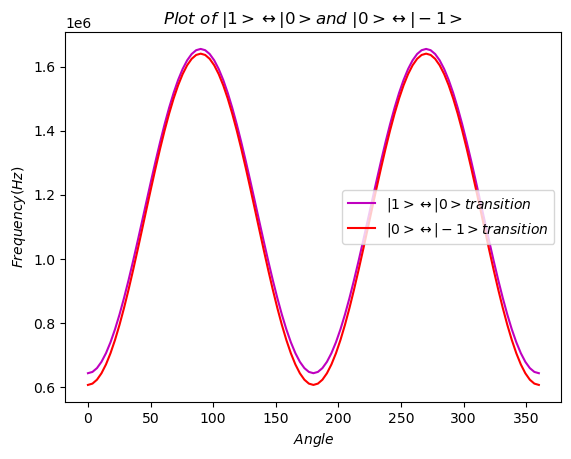

In [7]:
plt.plot(x,y_1D, '-m', label = r'$|1>\leftrightarrow|0> transition$')
plt.plot(x,-1*y_2D, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
plt.title(r'$Plot\ of\ |1>\leftrightarrow|0> and\ |0>\leftrightarrow|-1>$')
plt.legend()

plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')

In [8]:
df= pd.read_csv('freq_y_rot.csv', header = 0)
# input from file
x = df['angle']
y_s = df['fre_sum']
y_d = df['freq_diff']
y_1D = df['freq_1D'] #freq of |1> -> |0>
y_2D = df['freq_2D'] #freq of |0> -> |-1>

Text(0, 0.5, 'frequency (Hz)')

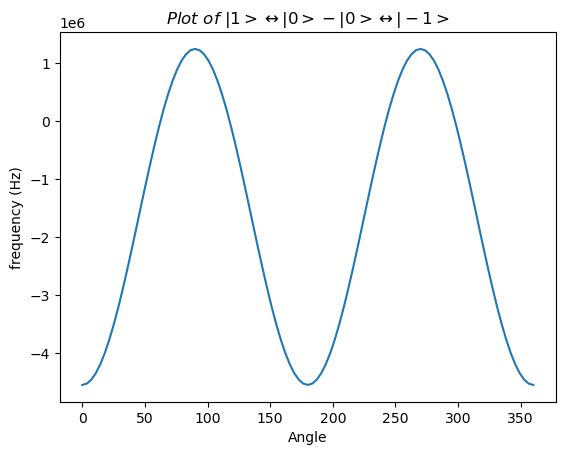

In [9]:
plt.plot(x,y_d, '-')
plt.title(r'$Plot\ of\ |1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
plt.xlabel("Angle")
plt.ylabel("frequency (Hz)")

Text(0, 0.5, '$Frequency (Hz)$')

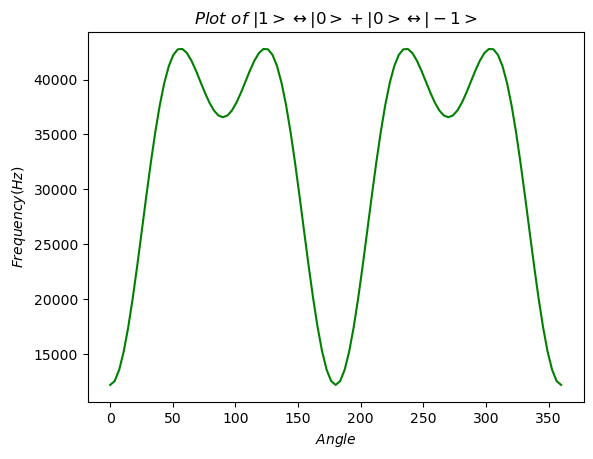

In [10]:
plt.plot(x,y_s, '-g')
plt.title(r'$Plot\ of\ |1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')

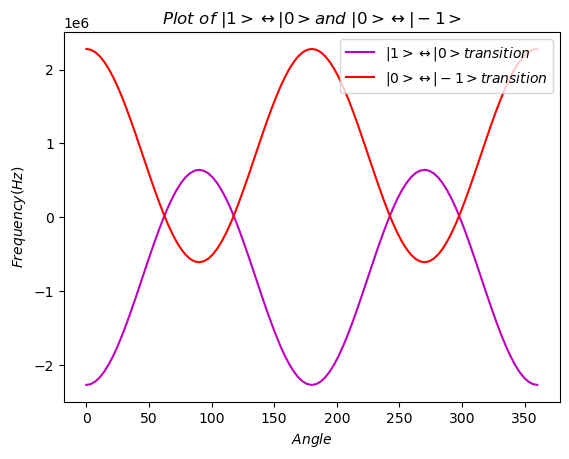

In [11]:
plt.plot(x,y_1D, '-m', label = r'$|1>\leftrightarrow|0> transition$')
plt.plot(x,y_2D, '-r',label = r'$|0>\leftrightarrow|-1> transition$')

plt.title(r'$Plot\ of\ |1>\leftrightarrow|0> and\ |0>\leftrightarrow|-1>$')
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')
plt.legend()

In [12]:
df= pd.read_csv('freq_x_rot.csv', header = 0)
# input from file
x = df['angle']
y_s = df['fre_sum']
y_d = df['freq_diff']
y_1D = df['freq_1D'] #freq of |1> -> |0>
y_2D = df['freq_2D'] #freq of |0> -> |-1>

Text(0, 0.5, 'frequency (Hz)')

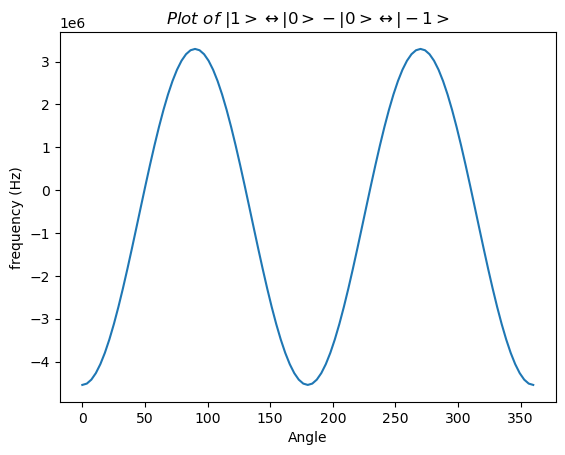

In [13]:
plt.plot(x,y_d, '-')
plt.title(r'$Plot\ of\ |1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
plt.xlabel("Angle")
plt.ylabel("frequency (Hz)")

Text(0, 0.5, '$Frequency (Hz)$')

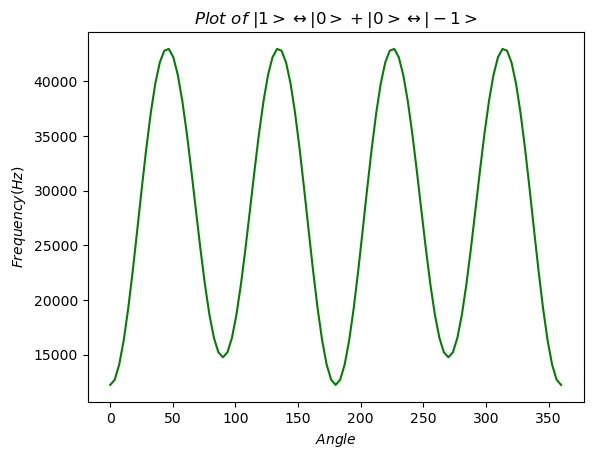

In [14]:
plt.plot(x,y_s, '-g')
plt.title(r'$Plot\ of\ |1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')

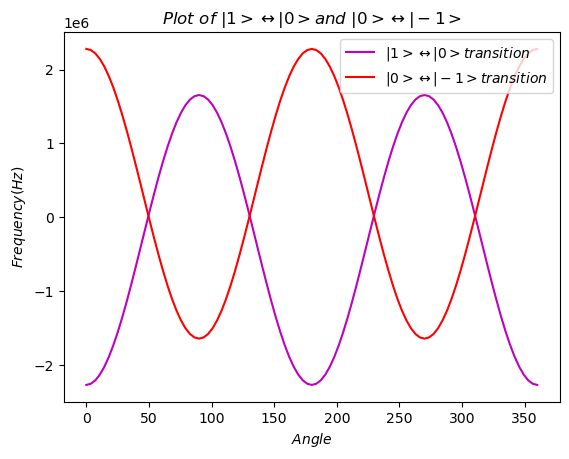

In [48]:
plt.plot(x,y_1D, '-m', label = r'$|1>\leftrightarrow|0> transition$')
plt.plot(x,y_2D, '-r',label = r'$|0>\leftrightarrow|-1> transition$')

plt.title(r'$Plot\ of\ |1>\leftrightarrow|0> and\ |0>\leftrightarrow|-1>$')
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')
plt.legend()

**Defining Functions**

In [16]:
#fitting functions
def Hcsa1(theta,A1, B1, C1):
    
    freq_csa1 = A1 + B1*np.cos(2*theta*np.pi/180) + C1*np.sin(2*theta*np.pi/180)
    return freq_csa1

def HQ2 (theta,A2, B2, C2, D2, E2):
    freq_Q2 = A2 + B2*np.cos(2*theta*np.pi/180) + C2*np.sin(2*theta*np.pi/180) + D2*np.cos(4*theta*np.pi/180) + E2*np.sin(4*theta*np.pi/180) 
    return freq_Q2

def fourier(theta, A,B,C,D,E, F, G, H, I) :
   freq_fourier = A + B*np.cos(1*theta*np.pi/180)+C*np.cos(3*theta*np.pi/180)+D*np.sin(1*theta*np.pi/180)+E*np.sin(3*theta*np.pi/180) + F*np.cos(2*theta*np.pi/180) + G*np.sin(2*theta*np.pi/180) + H*np.cos(4*theta*np.pi/180) + I*np.sin(4*theta*np.pi/180) 
   return freq_fourier

$H^1_Q$ is same as $H^1_{CSA}$

$H_{Q,ACS}$ same as $H^1_{CSA}$

$H_{Q,CSA}$ same as $H^2_{Q}$

**Fitting for Z rotation**

$\chi^2$ / $n_\mathrm{dof}$ = 0.98338 / 98
36.07152038982712
36.5683914826245


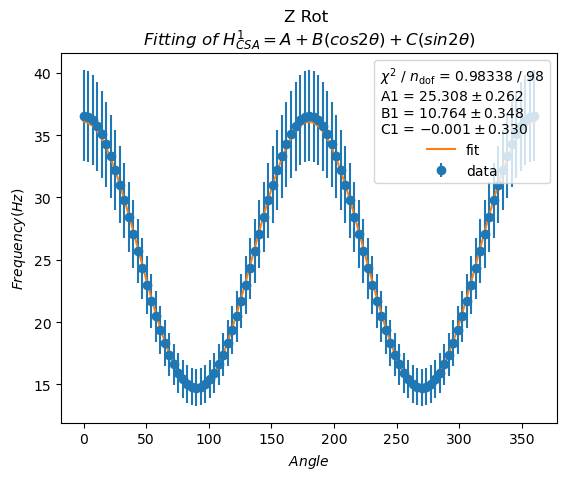

In [17]:
#Curve Fitting using Iminiuit

least_squares = LeastSquares(x, y_sz,y_sz/10, Hcsa1)
#least_squares = LeastSquares(x, y,y/10, HQ2)
m = Minuit(least_squares, A1 = 1, B1 = 1, C1= 1)
#m = Minuit(least_squares, A2 = 1, B2 = 1, C2= 1, D2 = 1, E2 = 1)
# m.fixed["C1"] = True

m.migrad()  # finds minimum of least_squares function
m.hesse()   # accurately computes uncertainties
fit_info = [
    f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m.fval:.5f} / {len(x) - m.nfit}",
]
print(fit_info[0])


for p, v, e in zip(m.parameters, m.values, m.errors):
    fit_info.append(f"{p} = ${v:.3f} \\pm {e:.3f}$")


# draw data and fitted line
plt.errorbar(x, y_sz, y_sz/10., fmt="o", label="data")
plt.plot(x, Hcsa1(x, *m.values), label="fit")
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (KHz)$')
plt.title('Z Rot \n'+r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
#ax11.plot(x, HQ2(x, *m.values), label="fit")
plt.legend(title="\n".join(fit_info))
# plt.savefig("miniuit_fit_Hcsa1")

print(Hcsa1(0, *m.values))
#print(HQ2(0, *m.values))
print(y_sz[0])

$\chi^2$ / $n_\mathrm{dof}$ = 0.00000 / 96
36.56839148262065
36.5683914826245


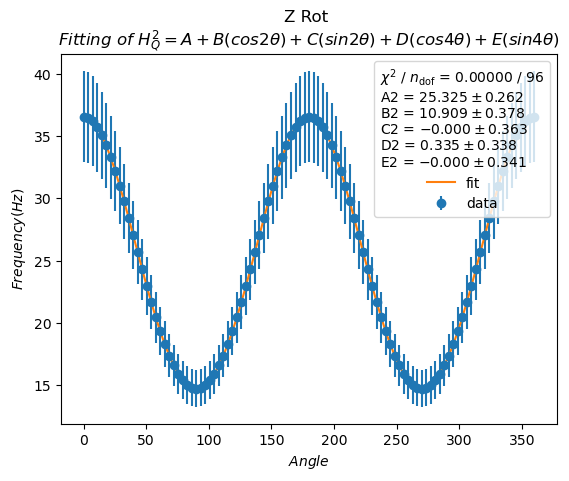

In [18]:
#Curve Fitting using Iminiuit

least_squares = LeastSquares(x, y_sz,y_sz/10, HQ2)
m = Minuit(least_squares, A2 = 1, B2 = 1, C2= 1, D2 = 1, E2 = 1)
# m.fixed["C1"] = True #if parameter needs to be fixed

m.migrad()  # finds minimum of least_squares function
m.hesse()   # accurately computes uncertainties
fit_info = [
    f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m.fval:.5f} / {len(x) - m.nfit}",
]
print(fit_info[0])


for p, v, e in zip(m.parameters, m.values, m.errors):
    fit_info.append(f"{p} = ${v:.3f} \\pm {e:.3f}$")


# draw data and fitted line
plt.errorbar(x, y_sz, y_sz/10., fmt="o", label="data")
plt.plot(x, HQ2(x, *m.values), label="fit")
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (KHz)$')
plt.title('Z Rot \n'+ r'$Fitting\ of\ H^2_{Q} = A + B(cos2\theta )+ C(sin2\theta) + D(cos4\theta) + E(sin4\theta)$')
#ax11.plot(x, HQ2(x, *m.values), label="fit")
plt.legend(title="\n".join(fit_info))
# plt.savefig("miniuit_fit_HQ2")

print(HQ2(0, *m.values))
#print(HQ2(0, *m.values))
print(y_sz[0])

$\chi^2$ / $n_\mathrm{dof}$ = 0.00000 / 98
1.2498684945251826
1.249875


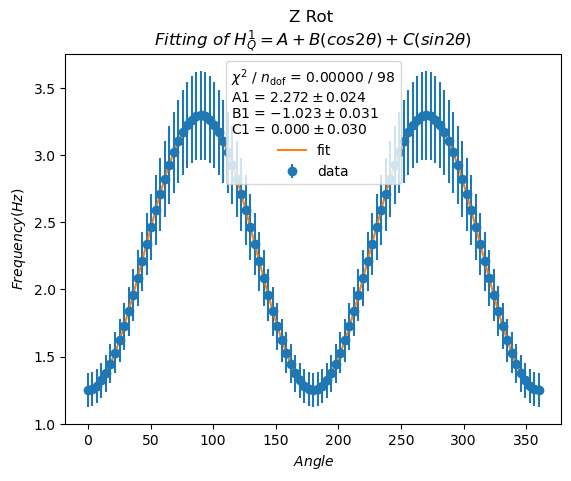

In [19]:
#Curve Fitting using Iminiuit

least_squares = LeastSquares(x, y_dz,y_dz/10, Hcsa1)

m = Minuit(least_squares, A1 = 1, B1 = 1, C1= 1)

# m.fixed["C1"] = True

m.migrad()  # finds minimum of least_squares function
m.hesse()   # accurately computes uncertainties
fit_info = [
    f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m.fval:.5f} / {len(x) - m.nfit}",
]
print(fit_info[0])


for p, v, e in zip(m.parameters, m.values, m.errors):
    fit_info.append(f"{p} = ${v:.3f} \\pm {e:.3f}$")


# draw data and fitted line
plt.errorbar(x, y_dz, y_dz/10., fmt="o", label="data")
plt.plot(x, Hcsa1(x, *m.values), label="fit")
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (MHz)$')
plt.title('Z Rot \n'+r'$Fitting\ of\ H^1_{Q} = A + B(cos2\theta )+ C(sin2\theta)$')
#ax11.plot(x, HQ2(x, *m.values), label="fit")
plt.legend(title="\n".join(fit_info))
# plt.savefig("miniuit_fit_HQ1")

print(Hcsa1(0, *m.values))
#print(HQ2(0, *m.values))
print(y_dz[0])

$\chi^2$ / $n_\mathrm{dof}$ = 0.00000 / 98
1.2498684945251826
1.249875


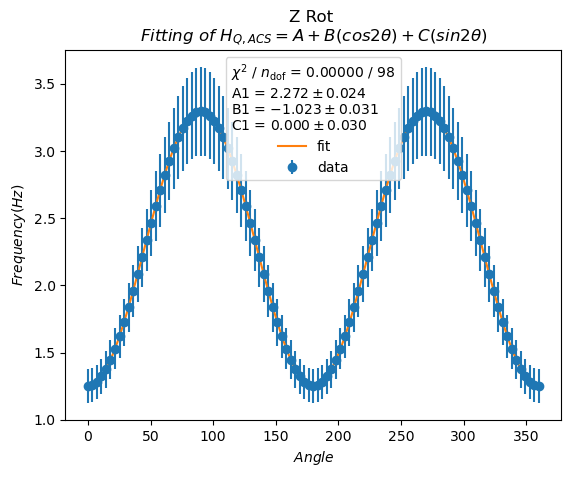

In [20]:
#Curve Fitting using Iminiuit

least_squares = LeastSquares(x, y_dz,y_dz/10, Hcsa1)

m = Minuit(least_squares, A1 = 1, B1 = 1, C1= 1)

# m.fixed["C1"] = True

m.migrad()  # finds minimum of least_squares function
m.hesse()   # accurately computes uncertainties
fit_info = [
    f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m.fval:.5f} / {len(x) - m.nfit}",
]
print(fit_info[0])


for p, v, e in zip(m.parameters, m.values, m.errors):
    fit_info.append(f"{p} = ${v:.3f} \\pm {e:.3f}$")


# draw data and fitted line
plt.errorbar(x, y_dz, y_dz/10., fmt="o", label="data")
plt.plot(x, Hcsa1(x, *m.values), label="fit")
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')
plt.title('Z Rot \n'+r'$Fitting\ of\ H_{Q,ACS} = A + B(cos2\theta )+ C(sin2\theta)$')
#ax11.plot(x, HQ2(x, *m.values), label="fit")
plt.legend(title="\n".join(fit_info))
# plt.savefig('Images/minuit_fit_HQ,ACS')

print(Hcsa1(0, *m.values))
#print(HQ2(0, *m.values))
print(y_dz[0])

$\chi^2$ / $n_\mathrm{dof}$ = 0.00000 / 96
1.249874999948942
1.249875


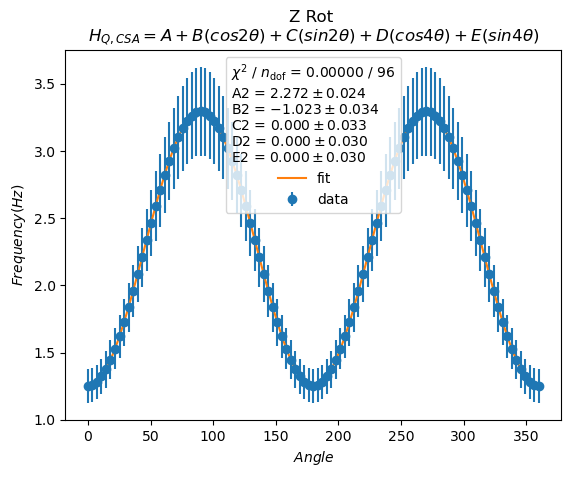

In [21]:
#Curve Fitting using Iminiuit

least_squares = LeastSquares(x, y_dz,y_dz/10, HQ2)
m = Minuit(least_squares, A2 = 1, B2 = 1, C2= 1, D2 = 1, E2 = 1)
# m.fixed["C1"] = True #if parameter needs to be fixed

m.migrad()  # finds minimum of least_squares function
m.hesse()   # accurately computes uncertainties
fit_info = [
    f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m.fval:.5f} / {len(x) - m.nfit}",
]
print(fit_info[0])


for p, v, e in zip(m.parameters, m.values, m.errors):
    fit_info.append(f"{p} = ${v:.3f} \\pm {e:.3f}$")


# draw data and fitted line
plt.errorbar(x, y_dz, y_dz/10., fmt="o", label="data")
plt.plot(x, HQ2(x, *m.values), label="fit")
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')
plt.title('Z Rot \n'+r'$ H_{Q,CSA} = A + B(cos2\theta )+ C(sin2\theta) + D(cos4\theta) + E(sin4\theta)$')
#ax11.plot(x, HQ2(x, *m.values), label="fit")
plt.legend(title="\n".join(fit_info))
# plt.savefig("miniuit_fit_HQ,CSA")

print(HQ2(0, *m.values))
#print(HQ2(0, *m.values))
print(y_dz[0])

**Fitting for X rotation**

In [22]:
#Curve Fitting using Iminiuit

least_squares = LeastSquares(x, y_sx, y_sx/10, fourier)
#least_squares = LeastSquares(x, y,y/10, HQ2)
m = Minuit(least_squares, A = 1, B=1 , C=1, D = 1, E = 1, F = 1, G = 1, H = 1, I = 1)

# m.fixed["A1"] = True
# m.fixed["B1"] = True
#m.fixed["C1"] = True
m.migrad()  # finds minimum of least_squares function
m.hesse()   # accurately computes uncertainties

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.049e-05 (chi2/ndof = 0.0)│              Nfcn = 301              │
│ EDM = 1.05e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   28.25   │   0.30    │            │            │         │         │       │
│ 1 │ B    │    0.0    │    0.4    │            │            │         │         │       │
│ 2 │ C    │   -0.0    │    0.4    │            │            │         │         │       │
│ 3 │ D    │   -0.0    │    0.4    │            │            │         │         │       │
│ 4 │ E    │    0.0    │    0.4    │            │            │         │         │       │
│ 5 │ F    │   -1.26   │   0.25    │            │            │         │         │       │
│ 6 │ G    │    0.0    │    0.5    │            │            │         │         │       │
│ 7 │ H    │   -14.8   │    0.4    │            │            │         │         │       │
│ 8 │ I    │    0.0    │    0.4    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────────────────────────────────────────────────────────────────────────┐
│   │         A         B         C         D         E         F         G         H         I │
├───┼───────────────────────────────────────────────────────────────────────────────────────────┤
│ A │    0.0898 -0.000265 -0.000293  2.45e-11  5.31e-11   -0.0045  3.69e-11   -0.0773 -2.34e-12 │
│ B │ -0.000265     0.132   -0.0821   2.9e-12   2.7e-11  -0.00167  6.16e-12  -0.00196 -1.01e-12 │
│ C │ -0.000293   -0.0821     0.137  -3.7e-12 -2.56e-12  -0.00185  2.91e-11  -0.00217 -4.09e-13 │
│ D │  2.45e-11   2.9e-12  -3.7e-12     0.139    0.0614 -8.33e-13 -1.92e-11 -3.41e-11  1.67e-12 │
│ E │  5.31e-11   2.7e-11 -2.56e-12    0.0614     0.132  1.24e-11  6.38e-12 -3.77e-11   3.8e-13 │
│ F │   -0.0045  -0.00167  -0.00185 -8.33e-13  1.24e-11    0.0636 -1.61e-11  -0.00862  1.51e-13 │
│ G │  3.69e-11  6.16e-12  2.91e-11 -1.92e-11  6.38e-12 -1.61e-11     0.207 -2.28e-11   -0.0118 │
│ H │   -0.0773  -0.00196  -0.00217 -3.41e-11 -3.77e-11  -0.00862 -2.28e-11     0.145     2e-12 │
│ I │ -2.34e-12 -1.01e-12 -4.09e-13  1.67e-12   3.8e-13  1.51e-13   -0.0118     2e-12     0.126 │
└───┴───────────────────────────────────────────────────────────────────────────────────────────┘

$\chi^2$ / $n_\mathrm{dof}$ = 0.00001 / 92
12.222009949646065
12.222156146265599


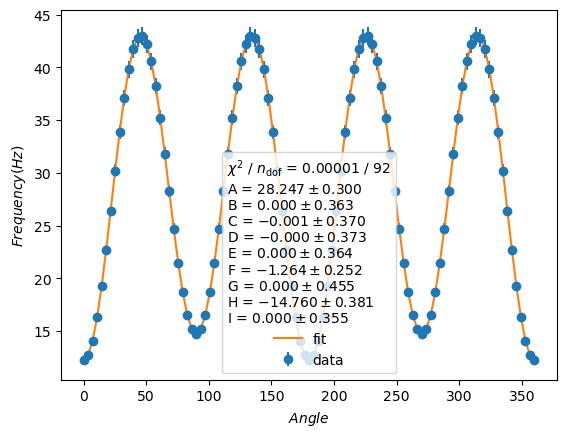

In [23]:

fit_info = [
    f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m.fval:.5f} / {len(x) - m.nfit}",
]
print(fit_info[0])


for p, v, e in zip(m.parameters, m.values, m.errors):
    fit_info.append(f"{p} = ${v:.3f} \\pm {e:.3f}$")


# draw data and fitted line
plt.errorbar(x, y_sx, y_sx/50., fmt="o", label="data")
plt.plot(x, fourier(x, *m.values), label="fit")
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')
#plt.title('X Rot \n'+r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
#ax11.plot(x, HQ2(x, *m.values), label="fit")
plt.legend(title="\n".join(fit_info))
# plt.savefig("miniuit_fit_Hcsa1")

print(fourier(0, *m.values))
#print(HQ2(0, *m.values))
print(y_sx[0])

In [24]:
(max(y_sx) - min(y_sx))/2

15.3736102055969

In [25]:
#Curve Fitting using Iminiuit
yerr = 0.1


# least_squares = LeastSquares(x, y_sx, yerr, Hcsa1)

least_squares = LeastSquares(x, y_sx,y_sx/10, HQ2)
m = Minuit(least_squares, A2 = 1, B2 = 1, C2= 0, D2=1,E2=1)

# m.fixed["A1"] = True
# m.fixed["B1"] = Truessetion
m.hesse()   # accurately computes uncertainties

┌─────────────────────────────────────────────────────────────────────────┐
│                               External                                  │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9035 (chi2/ndof = 94.1)    │              Nfcn = 74               │
│ EDM = 3.55 (Goal: 0.0002)        │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ ABOVE EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A2   │  1.0000   │  0.0021   │            │            │         │         │       │
│ 1 │ B2   │  1.0000   │  0.0021   │            │            │         │         │       │
│ 2 │ C2   │     0     │     4     │            │            │         │         │       │
│ 3 │ D2   │  1.0000   │  0.0021   │            │            │         │         │       │
│ 4 │ E2   │   1.000   │   0.004   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────────────────────────┐
│    │        A2        B2        C2        D2        E2 │
├────┼───────────────────────────────────────────────────┤
│ A2 │  4.44e-06  -6.1e-11  2.27e-10 -2.27e-10 -2.82e-13 │
│ B2 │  -6.1e-11  4.44e-06 -6.81e-09 -5.22e-11  8.45e-12 │
│ C2 │  2.27e-10 -6.81e-09      14.3  6.81e-10   -0.0128 │
│ D2 │ -2.27e-10 -5.22e-11  6.81e-10  4.44e-06 -8.45e-13 │
│ E2 │ -2.82e-13  8.45e-12   -0.0128 -8.45e-13  1.59e-05 │
└────┴───────────────────────────────────────────────────┘

$\chi^2$ / $n_\mathrm{dof}$ = 9034.69212 / 96
3.0
-4.545


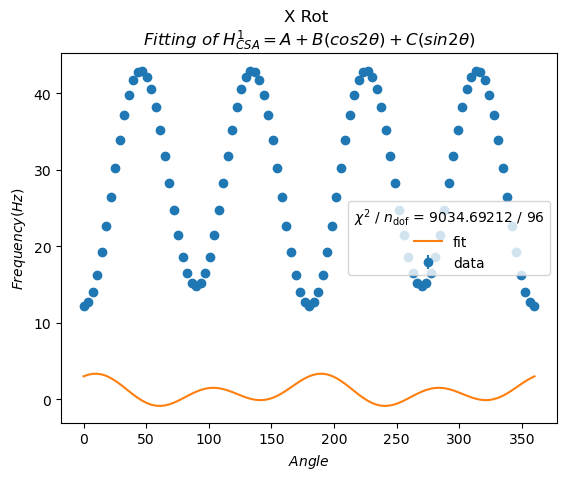

In [26]:

fit_info = [
    f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m.fval:.5f} / {len(x) - m.nfit}",
]
print(fit_info[0])


plt.errorbar(x, y_sx, yerr, fmt="o", label="data")
# plt.plot(x, Hcsa1(x, *m.values), label="fit")
plt.plot(x, HQ2(x, *m.values), label="fit")
plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')
plt.title('X Rot \n'+r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
#ax11.plot(x, HQ2(x, *m.values), label="fit")
plt.legend(title="\n".join(fit_info))
# plt.savefig("miniuit_fit_Hcsa1")

# print(Hcsa1(0, *m.values))
print(HQ2(0, *m.values))
print(y_dx[0])

In [27]:
# from jacobi import jacobi
# lsq.visualize(m.values)

# y, ycov = propagate(lambda p: Hcsa1(x, *p), m.values, m.covariance)
# ye = np.diag(ycov) **0.5

# plt.fill_between(x, y -ye, y+ye)

#### y-direction

In [36]:
#Curve Fitting using Iminiuit
yerr = 0.1


# least_squares = LeastSquares(x, y_sx, yerr, Hcsa1)

least_squares = LeastSquares(x, y_sy,y_sy/10, fourier)
m = Minuit(least_squares, A = 100, B = 100, C = 100, D = 1000, E = 1000, F = 1, G = 1, H = 1, I = 1)

m.hesse()   # accurately computes uncertainties

┌─────────────────────────────────────────────────────────────────────────┐
│                               External                                  │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.233e+07 (chi2/ndof = 134074.9)│              Nfcn = 156              │
│ EDM = 1.23e+07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ ABOVE EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  100.00   │   0.34    │            │            │         │         │       │
│ 1 │ B    │   100.0   │    0.4    │            │            │         │         │       │
│ 2 │ C    │   100.0   │    0.4    │            │            │         │         │       │
│ 3 │ D    │ 1.0000e3  │ 0.0005e3  │            │            │         │         │       │
│ 4 │ E    │ 1.0000e3  │ 0.0004e3  │            │            │         │         │       │
│ 5 │ F    │    1.0    │    0.4    │            │            │         │         │       │
│ 6 │ G    │    1.0    │    0.5    │            │            │         │         │       │
│ 7 │ H    │    1.0    │    0.4    │            │            │         │         │       │
│ 8 │ I    │    1.0    │    0.4    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────────────────────────────────────────────────────────────────────────┐
│   │         A         B         C         D         E         F         G         H         I │
├───┼───────────────────────────────────────────────────────────────────────────────────────────┤
│ A │     0.115 -0.000188 -0.000368  4.34e-05 -6.91e-06   -0.0673  4.41e-06   -0.0395  -5.4e-06 │
│ B │ -0.000188     0.157    -0.125 -5.85e-06  5.06e-06 -0.000721 -4.54e-06  -0.00147  8.08e-06 │
│ C │ -0.000368    -0.125     0.193  1.94e-06 -3.83e-06  -0.00167  4.85e-06  -0.00311 -9.94e-06 │
│ D │  4.34e-05 -5.85e-06  1.94e-06     0.287    -0.047 -0.000122 -2.37e-05  5.21e-05   2.6e-06 │
│ E │ -6.91e-06  5.06e-06 -3.83e-06    -0.047     0.171  1.45e-05  1.72e-07  4.43e-07  3.83e-06 │
│ F │   -0.0673 -0.000721  -0.00167 -0.000122  1.45e-05     0.178 -2.23e-05   -0.0752  1.57e-05 │
│ G │  4.41e-06 -4.54e-06  4.85e-06 -2.37e-05  1.72e-07 -2.23e-05     0.266  1.16e-05   -0.0964 │
│ H │   -0.0395  -0.00147  -0.00311  5.21e-05  4.43e-07   -0.0752  1.16e-05     0.184 -3.61e-06 │
│ I │  -5.4e-06  8.08e-06 -9.94e-06   2.6e-06  3.83e-06  1.57e-05   -0.0964 -3.61e-06      0.18 │
└───┴───────────────────────────────────────────────────────────────────────────────────────────┘

$\chi^2$ / $n_\mathrm{dof}$ = 12334891.52588 / 92
302.0
12.222156146265599


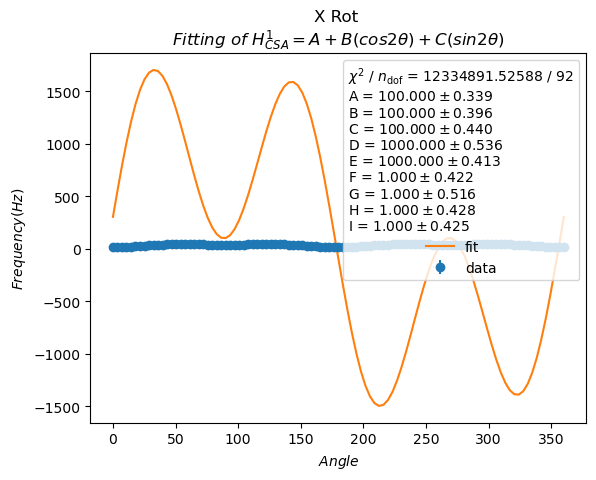

In [37]:
fit_info = [
    f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m.fval:.5f} / {len(x) - m.nfit}",
]
print(fit_info[0])

for p, v, e in zip(m.parameters, m.values, m.errors):
    fit_info.append(f"{p} = ${v:.3f} \\pm {e:.3f}$")

plt.errorbar(x, y_sy, y_sy/10, fmt="o", label="data")
plt.plot(x, fourier(x, *m.values), label="fit")

plt.xlabel(r'$Angle$')
plt.ylabel(r'$Frequency (Hz)$')
plt.title('X Rot \n'+r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
plt.legend(title="\n".join(fit_info))
# plt.savefig("miniuit_fit_Hcsa1")

print(fourier(0, *m.values))
#print(HQ2(0, *m.values))
print(y_sy[0])